# <center> Практика. Статистические тесты в контексте EDA

## Постановка задачи

HR-агентство изучает тренды на рынке труда в IT. Компания хочет провести исследование на основе данных о зарплатах в сфере Data Science за 2020–2022 годы и получить некоторые выводы.

В процессе своего анализа мы должны:

1) Выяснить, какие факторы влияют на зарплату специалиста Data Scientist.
2) А также ответить на ключевые вопросы HR-агентства:
    - Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?
    - Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?
    - Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?
    - Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?
3) Дополнительные бизнес вопросы:
    - Насколько сильное влияние оказывает опыт работы на зарплаты специалистов Data Scientist?
    - Существует ли статистически значимая разница в зарплатах между разными форматами работы (полностью/частично/не удалённо)?



На каждый вопрос необходимо ответить с уровнем значимости $\alpha=0.05$.

Ответить на эти вопросы нам помогут данные о зарплатах в сфере Data Science за 2020–2022 годы.

### Данные содержат следующие столбцы:

- **`work_year`** — Год, в котором была выплачена зарплата.

- **`experience_level`** — Опыт работы на этой должности в течение года. Возможные значения:
    - **EN** — Entry-level/Junior.
    - **MI** — Mid-level/Intermediate.
    - **SE** — Senior-level/Expert.
    - **EX** — Executive-level/Director.

- **`employment_type`** — Тип трудоустройства для этой роли. Возможные значения:
    - **PT** — неполный рабочий день.
    - **FT** — полный рабочий день.
    - **CT** — контракт.
    - **FL** — фриланс.

- **`job_title`** — Роль, в которой соискатель работал в течение года.

- **`salary`** — Общая выплаченная валовая сумма заработной платы.

- **`salary_currency`** — Валюта выплачиваемой заработной платы (в виде кода валюты ISO 4217).

- **`salary_in_usd`** — Зарплата в долларах США (валюта пересчитана по среднему значению курса доллара США за соответствующий год через `fxdata.foorilla.com`).

- **`employee_residence`** — Основная страна проживания сотрудника в течение рабочего года (в виде кода страны ISO 3166).

- **`remote_ratio`** — Общий объём работы, выполняемой удалённо. Возможные значения:
    - **0** — удалённой работы нет (менее 20 %).
    - **50** — частично удалённая работа.
    - **100** — полностью удалённая работа (более 80 %).

- **`company_location`** — Страна главного офиса работодателя или филиала по контракту (в виде кода страны ISO 3166).

- **`company_size`** — Среднее количество людей, работавших в компании в течение года. Возможные значения:
    - **S** — менее 50 сотрудников (небольшая компания).
    - **M** — от 50 до 250 сотрудников (средняя компания).
    - **L** — более 250 сотрудников (крупная компания).

Источник датасета: [“Data Science Job Salaries” (kaggle.com)](https://www.kaggle.com/datasets/ruchi798/data-science-job-salaries)

## Загрузка данных

In [2]:
# загружаем необходимые библиотеки
import pandas as pd
import numpy as np

from scipy import stats
import statsmodels.api as sm
from statsmodels import stats as sms

import matplotlib.pyplot as plt
import seaborn as sns

# делаем визуальную настройку графиков
sns.set_theme("notebook") 
sns.set_palette("Set2")

In [3]:
# загружаем датасет
data = pd.read_csv('https://lms.skillfactory.ru/asset-v1:SkillFactory+DST-3.0+28FEB2021+type@asset+block@ds_salaries.zip', index_col=0)
data.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [4]:
# задаём уровень значимости
alpha = 0.05 
print("Уровень значимости alpha = {:.2f}".format(alpha))

Уровень значимости alpha = 0.05


## Описательный анализ данных

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary              607 non-null    int64 
 5   salary_currency     607 non-null    object
 6   salary_in_usd       607 non-null    int64 
 7   employee_residence  607 non-null    object
 8   remote_ratio        607 non-null    int64 
 9   company_location    607 non-null    object
 10  company_size        607 non-null    object
dtypes: int64(4), object(7)
memory usage: 56.9+ KB


В датасете 607 записей (без пропущенных значений).


In [6]:
# Проверим данные на наличие полных дубликатов:
print('Количество дубликатов: {}'.format(data[data.duplicated()].shape[0]))

# Удаляем дубликаты:
data = data.drop_duplicates()
print('Размер таблицы после удаления дубликатов: {}'.format(data.shape))

Количество дубликатов: 42
Размер таблицы после удаления дубликатов: (565, 11)


### Классификация признаков

**Числовые признаки:**
1. `work_year` — Год выплаты зарплаты (число: 2020, 2021, 2022).
2. `salary` — Общая сумма валовой зарплаты.
3. `salary_in_usd` — Зарплата в долларах США.
4. `remote_ratio` — Процент удалённой работы (числовые значения: 0, 50, 100).

**Категориальные признаки:**
1. `experience_level` — Опыт работы на должности (`EN`, `MI`, `SE`, `EX`).
2. `employment_type` — Тип трудоустройства (`PT`, `FT`, `CT`, `FL`).
3. `job_title` — Название должности.
4. `salary_currency` — Валюта зарплаты (например, `USD`, `EUR`, `GBP`).
5. `employee_residence` — Основная страна проживания сотрудника (ISO 3166 код, например, `US`, `DE`, `JP`).
6. `company_location` — Страна местоположения компании (ISO 3166 код).
7. `company_size` — Размер компании (`S`, `M`, `L`).

### Список неинформативных признаков

Для данных вопросов следующие признаки будут **удалены из анализа**, так как они не полезны для исследования:
- `salary` — есть поле `salary_in_usd`.
- `salary_currency` — есть поле `salary_in_usd`.
- `employee_residence` - - местожительство сотрудника не связано с ключевыми вопросами.



In [7]:
# Удалим неинформативные признаки
data = data.drop(['salary', 'salary_currency', 'employee_residence'], axis=1)

In [8]:
# Создадим два новых признака data_scientist и data_engineer
data_engineer_keywords = ['architect', 'data engineer', 'etl', 'infrastructure']

data['tmp'] = data['job_title'].apply(lambda title: 'DE' if any(keyword in title.lower() for keyword in data_engineer_keywords) else 'DS')
data = data.drop('job_title', axis=1)
data = data.rename(columns={'tmp': 'job_title'})

In [9]:
# Основные статистические характеристики для числовых признаков
data.describe().round(2)

,work_year,salary_in_usd,remote_ratio
count,565.00,565.00,565.00
mean,2021.36,110610.34,69.91
std,0.70,72280.70,40.90
min,2020.00,2859.00,0.00
25%,2021.00,60757.00,50.00
50%,2021.00,100000.00,100.00
75%,2022.00,150000.00,100.00
max,2022.00,600000.00,100.00


In [10]:
# Основные статистические характеристики для категориальных признаков
data.select_dtypes(include=['object', 'boolean']).describe()

,experience_level,employment_type,company_location,company_size,job_title
count,565,565,565,565,565
unique,4,4,50,3,2
top,SE,FT,US,M,DS
freq,243,546,318,290,402


### Распределение зарплат

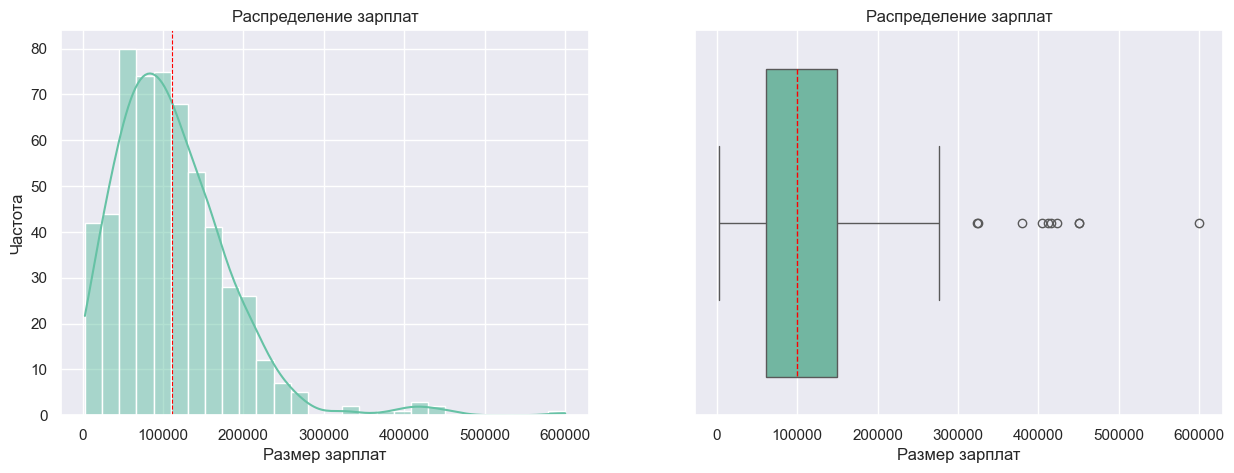

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data['salary_in_usd'], kde=True, ax=axes[0])
axes[0].set(xlabel='Размер зарплат', ylabel='Частота')
axes[0].set_title('Распределение зарплат')
axes[0].axvline(data['salary_in_usd'].mean(), color='red', linestyle='--', linewidth=0.8)

sns.boxplot(data['salary_in_usd'], ax=axes[1], orient='h', medianprops={"color": "red", "linestyle": '--'})
axes[1].set(xlabel='Размер зарплат')
axes[1].set_title('Распределение зарплат')

plt.show()

In [12]:
data_agg = data['salary_in_usd'].describe().round(2).to_frame()
data_agg.columns = ['Размер зарплат']
data_agg

,Размер зарплат
count,565.00
mean,110610.34
std,72280.70
min,2859.00
25%,60757.00
50%,100000.00
75%,150000.00
max,600000.00


Распределение зарплат отлично от нормального, имеются выбросы.

### Влияние опыта работы на зарплаты специалистов Data Scientist

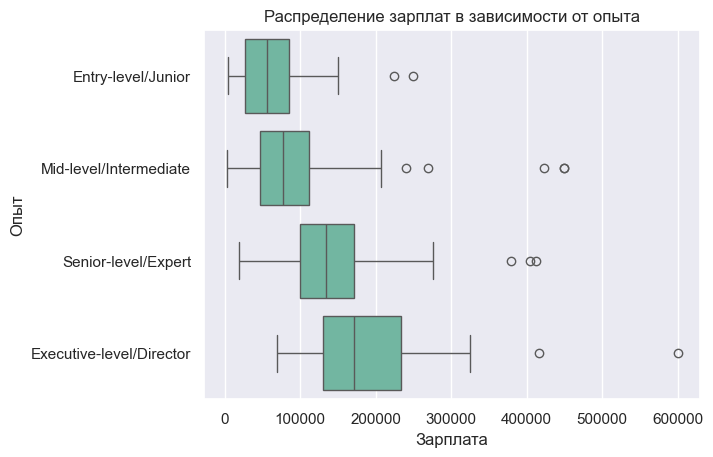

In [13]:
fig = sns.boxplot(data=data, y="experience_level", x="salary_in_usd", orient='h', order=["EN", "MI", "SE", "EX"])
fig.set_yticks(range(4))
fig.set_yticklabels(["Entry-level/Junior", "Mid-level/Intermediate", "Senior-level/Expert", "Executive-level/Director"])
fig.set_title("Распределение зарплат в зависимости от опыта")
fig.set(xlabel='Зарплата', ylabel='Опыт')
plt.show()

In [14]:
data_agg = data.groupby('experience_level')['salary_in_usd'].describe().round(2)
print('Распределение зарплат в зависимости от опыта')
data_agg

Распределение зарплат в зависимости от опыта


,count,mean,std,min,25%,50%,75%,max
experience_level,,,,,,,,
EN,88.0,61643.32,44395.54,4000.0,27505.00,56500.0,85425.75,250000.0
EX,26.0,199392.04,117071.26,69741.0,130006.50,171437.5,233750.00,600000.0
MI,208.0,87793.00,64118.97,2859.0,47163.75,76940.0,112075.00,450000.0
SE,243.0,138374.88,59955.97,18907.0,99531.50,135000.0,171881.00,412000.0


На графике видно, что уровень зарплаты напрямую зависит от опыта

### Распределение заработной платы по годам

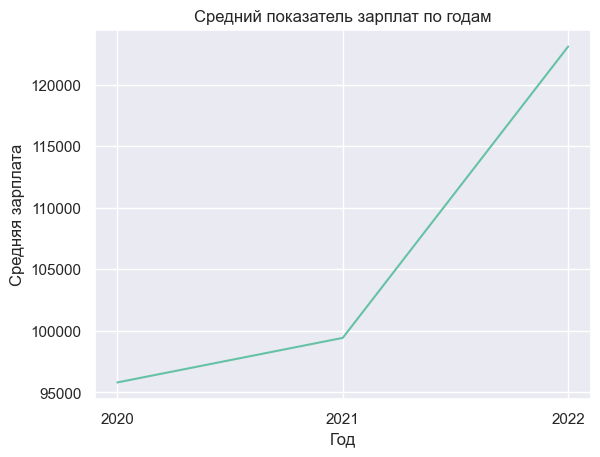

In [15]:
avg_salary_by_year = data.groupby('work_year')['salary_in_usd'].mean().reset_index()

fig = sns.lineplot(data=avg_salary_by_year, x="work_year", y="salary_in_usd")
plt.xticks(ticks=range(data["work_year"].min(), data["work_year"].max() + 1))
fig.set_title("Средний показатель зарплат по годам")
fig.set(xlabel='Год', ylabel='Средняя зарплата')
plt.show()

In [16]:
data_agg = data.groupby('work_year')['salary_in_usd'].describe().round(2)
print('Распределение заработной платы по годам')
data_agg

Распределение заработной платы по годам


,count,mean,std,min,25%,50%,75%,max
work_year,,,,,,,,
2020,72.0,95813.00,82831.80,5707.0,45724.5,75544.0,115526.0,450000.0
2021,215.0,99430.41,80304.32,2859.0,50000.0,82528.0,135000.0,600000.0
2022,278.0,123089.10,59888.93,10000.0,78791.0,120000.0,160000.0,405000.0


На графике четко виден ежегодный рост зарплат у специалистов Data Scientist

### Распределение зарплат в зависимости от типа трудоустройства

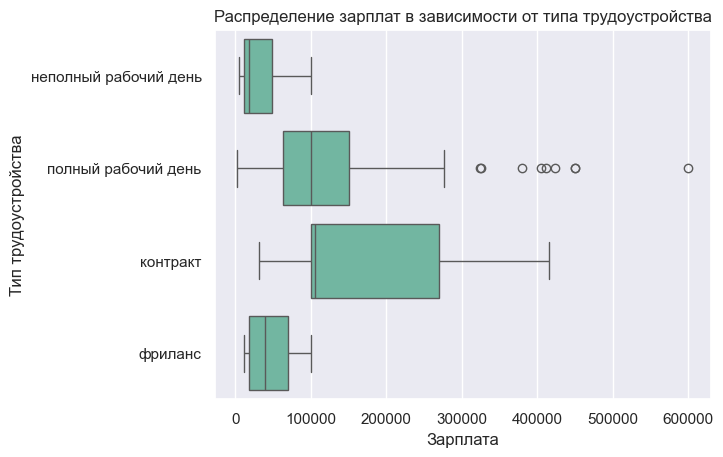

In [17]:
fig = sns.boxplot(data=data, y="employment_type", x="salary_in_usd", orient='h', order=["PT", "FT", "CT", "FL"])
fig.set_yticks(range(4))
fig.set_yticklabels(["неполный рабочий день", "полный рабочий день", "контракт", "фриланс"])
fig.set_title("Распределение зарплат в зависимости от типа трудоустройства")
fig.set(xlabel='Зарплата', ylabel='Тип трудоустройства')
plt.show()

In [18]:
data_agg = data.groupby('employment_type')['salary_in_usd'].describe().round(2)
print("Распределение зарплат в зависимости от типа трудоустройства")
data_agg

Распределение зарплат в зависимости от типа трудоустройства


,count,mean,std,min,25%,50%,75%,max
employment_type,,,,,,,,
CT,5.0,184575.00,156250.89,31875.0,100000.0,105000.0,270000.0,416000.0
FL,4.0,48000.00,40529.82,12000.0,18000.0,40000.0,70000.0,100000.0
FT,546.0,111811.84,70790.70,2859.0,62726.0,100000.0,150000.0,600000.0
PT,10.0,33070.50,31472.91,5409.0,12000.0,18817.5,48370.0,100000.0


На графике видно, что контракторы зарабатывают больше всего однако недостаточно количество данных для однозначного вывода

### Распределение зарплат в зависимости от объёма работы, выполняемой удалённо

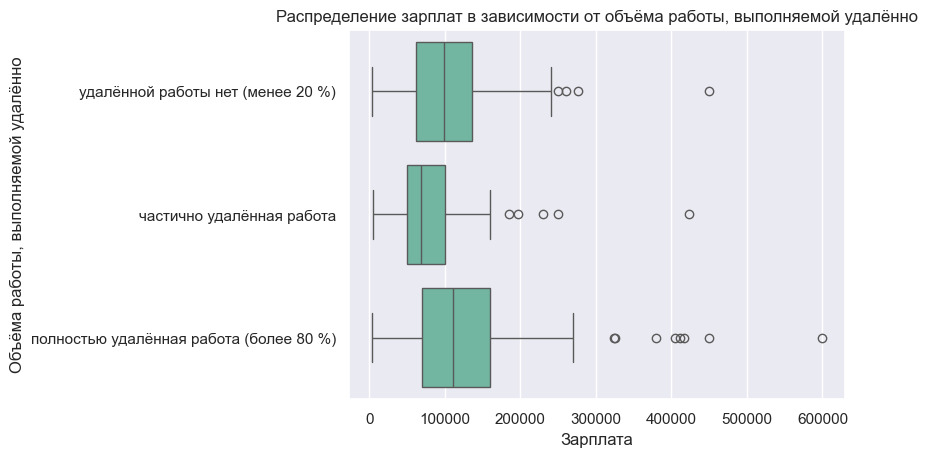

In [19]:
fig = sns.boxplot(data=data, y="remote_ratio", x="salary_in_usd", orient='h')
fig.set_yticks(range(3))
fig.set_yticklabels(["удалённой работы нет (менее 20 %)", "частично удалённая работа", "полностью удалённая работа (более 80 %)"])
fig.set_title("Распределение зарплат в зависимости от объёма работы, выполняемой удалённо")
fig.set(xlabel='Зарплата', ylabel='Объёма работы, выполняемой удалённо')
plt.show()

In [20]:
data_agg = data.groupby('remote_ratio')['salary_in_usd'].describe().round(2)
print("Распределение зарплат в зависимости от объёма работы, выполняемой удалённо")
data_agg

Распределение зарплат в зависимости от объёма работы, выполняемой удалённо


,count,mean,std,min,25%,50%,75%,max
remote_ratio,,,,,,,,
0,121.0,105785.40,68392.50,2859.0,62000.0,98158.0,136000.00,450000.0
50,98.0,80721.90,57639.10,5409.0,50000.5,68010.5,99925.75,423000.0
100,346.0,120763.19,74930.43,4000.0,70000.0,110712.5,159750.00,600000.0


По графику видно, что больше всего денег зарабатывают люди полностью работающие удаленно или полностью работающие в офисе

### Распределение зарплат в зависимости от местоположения компании

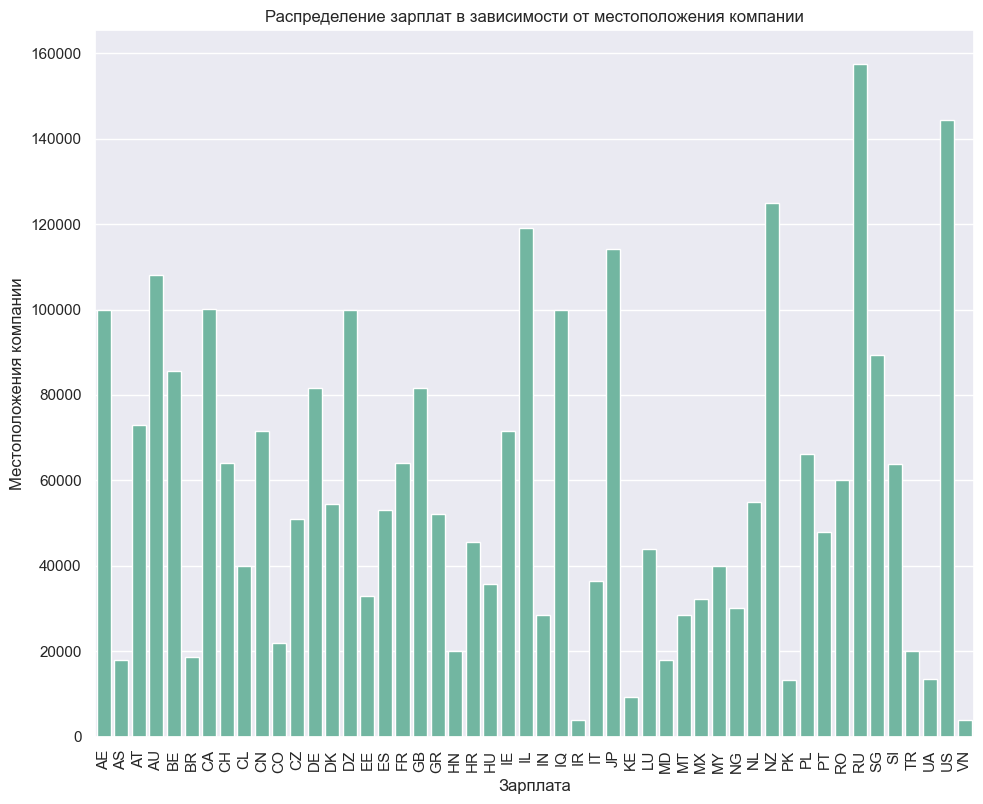

In [21]:
plt.figure(figsize=(10, 8))
avg_salary_by_location = data.groupby('company_location')['salary_in_usd'].mean().reset_index()

fig = sns.barplot(data=avg_salary_by_location, x="company_location", y="salary_in_usd")
plt.xticks(rotation=90)
plt.tight_layout()

fig.set_title("Распределение зарплат в зависимости от местоположения компании")
fig.set(xlabel='Зарплата', ylabel='Местоположения компании')
plt.show()

In [22]:
data_agg = data.groupby('company_location')['salary_in_usd'].describe().round(2)
print("Распределение зарплат в зависимости от местоположения компании")
data_agg

Распределение зарплат в зависимости от местоположения компании


,count,mean,std,min,25%,50%,75%,max
company_location,,,,,,,,
AE,3.0,100000.00,30413.81,65000.0,90000.00,115000.0,117500.00,120000.0
AS,1.0,18053.00,NaN,18053.0,18053.00,18053.0,18053.00,18053.0
AT,4.0,72920.75,13332.78,61467.0,64003.50,69489.5,78406.75,91237.0
AU,3.0,108042.67,36337.91,86703.0,87064.00,87425.0,118712.50,150000.0
BE,2.0,85699.00,4179.00,82744.0,84221.50,85699.0,87176.50,88654.0
BR,3.0,18602.67,5555.76,12901.0,15904.00,18907.0,21453.50,24000.0
CA,28.0,100121.86,47080.71,52000.0,70518.00,81895.5,117374.75,225000.0
CH,2.0,64114.00,82352.48,5882.0,34998.00,64114.0,93230.00,122346.0
CL,1.0,40038.00,NaN,40038.0,40038.00,40038.0,40038.00,40038.0


По графику трудно оценить где самая высока зарплата из-за отсутствия одинакового количества информации о зарплатах в каждой локации

### Соотношение зарплаты Data Scientist и Data Engineer в 2022 году

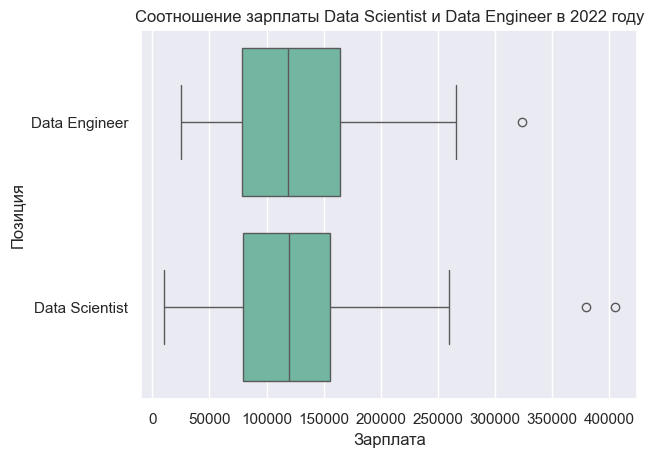

In [23]:
data_2022 = data[data['work_year'] == 2022]
fig = sns.boxplot(data=data_2022, y="job_title", x="salary_in_usd")
fig.set_yticks(range(2))
fig.set_yticklabels(["Data Engineer", "Data Scientist"])
fig.set_title("Соотношение зарплаты Data Scientist и Data Engineer в 2022 году")
fig.set(xlabel='Зарплата', ylabel='Позиция')
plt.show()

In [24]:
data_agg = data_2022.groupby('job_title')['salary_in_usd'].describe().round(2)
print("Соотношение зарплаты Data Scientist и Data Engineer в 2022 году")
data_agg

Соотношение зарплаты Data Scientist и Data Engineer в 2022 году


,count,mean,std,min,25%,50%,75%,max
job_title,,,,,,,,
DE,90.0,128172.26,59538.94,25000.0,78526.0,119093.5,164070.0,324000.0
DS,188.0,120655.67,60061.38,10000.0,78977.0,120000.0,155500.0,405000.0


На основе графика можно сделать предположение, что зарплаты Data Scientist и Data Engineer в 2022 году было практически одинаковыми. Однако максимальная зарплата Data Engineer было немного выше

### Соотношение зарплаты специалистов Data Scientist в компаниях различных размеров

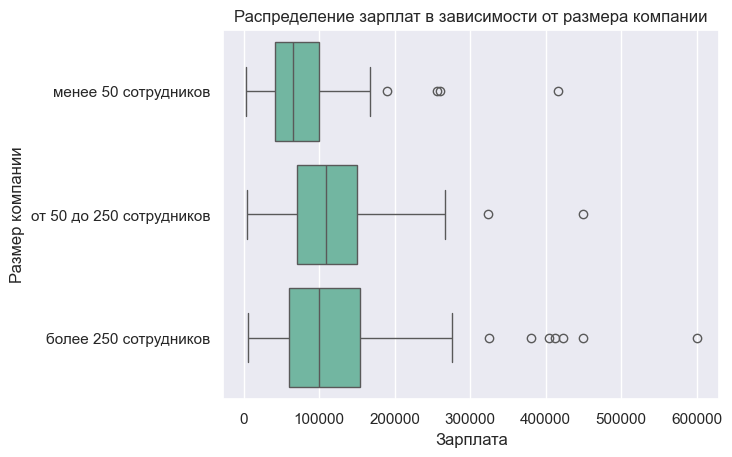

In [25]:
fig = sns.boxplot(data=data, y="company_size", x="salary_in_usd", orient='h', order=['S', 'M', 'L'])
fig.set_yticks(range(3))
fig.set_yticklabels(["менее 50 сотрудников", "от 50 до 250 сотрудников", "более 250 сотрудников"])
fig.set_title("Распределение зарплат в зависимости от размера компании")
fig.set(xlabel='Зарплата', ylabel='Размер компании')
plt.show()

In [26]:
data_agg = data.groupby('company_size')['salary_in_usd'].describe().round(2)
print("Распределение зарплат в зависимости от размера компании")
data_agg

Распределение зарплат в зависимости от размера компании


,count,mean,std,min,25%,50%,75%,max
company_size,,,,,,,,
L,193.0,118213.88,86753.27,5882.0,60000.0,100000.0,153667.00,600000.0
M,290.0,114807.08,60779.04,4000.0,70821.5,109640.0,150213.75,450000.0
S,82.0,77872.10,63814.52,2859.0,41816.0,65511.0,100000.00,416000.0


По графику видно, что меньше всего зарабатывают люди работающие в маленьких компаниях. В средних и больших копаниях люди зарабатывают практически одинаково

### Взаимосвязь между наличием должностей Data Scientist и Data Engineer и размером компании

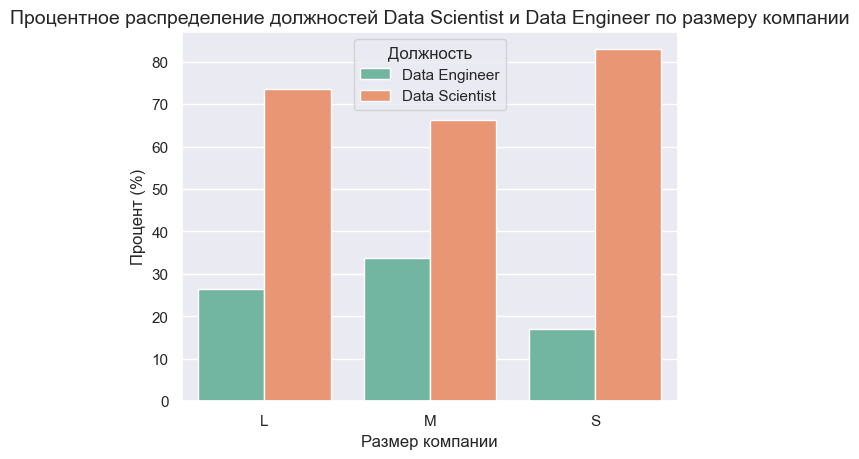

In [27]:
cross_tab = (pd.crosstab(index=data['job_title'], columns=data['company_size'], normalize='columns') * 100).round(2)
cross_tab = cross_tab.rename(index={"DS": "Data Scientist", "DE": "Data Engineer"})
cross_tab_reset = cross_tab.reset_index().melt(id_vars="job_title", var_name="company_size", value_name="percentage")

fig = sns.barplot(data=cross_tab_reset, x="company_size", y="percentage", hue="job_title", palette="Set2")
fig.set_title("Процентное распределение должностей Data Scientist и Data Engineer по размеру компании", fontsize=14)
fig.set(xlabel="Размер компании", ylabel="Процент (%)")
fig.legend(title="Должность")

plt.show()

Согласно данным, в маленьких компаниях больше Data Scientist чем Data Engineer. В средних и больших компаниях процент примерно одинаковый. Чтобы определить, являются ли эти различия статистически значимыми, в следующем разделе мы проведём статистические тесты.

## Итоги
### Основные факторы, которые влияют на зарплату:
1. **Уровень опыта (`experience_level`)**:
    - Специалисты с более высоким уровнем опыта, такие как Senior (`SE`) или Executive (`EX`), получают значительно больше, чем Junior (`EN`) и Intermediate (`MI`).

2. **Год выплаты (`work_year`)**:
    - Зарплаты растут ежегодно, что связано с инфляцией, высокими темпами роста IT-рынка или увеличением спроса на специалистов.

3. **Тип занятости (`employment_type`)**:
    - Полный рабочий день (`FT`) и контрактная основа (`CT`) часто ассоциируются с более высокой заработной платой по сравнению с частичной занятостью (`PT`) или фрилансом (`FL`).

4. **Размер компании (`company_size`)**:
    - Крупные компании (`L`) и средние (`M`) чаще платят выше, чем небольшие (`S`), из-за большего бюджета и корпоративных возможностей.

5. **Удалённая работа (`remote_ratio`)**:
    - Полностью удалённые позиции (`100`) могут ассоциироваться с более высокой зарплатой, так как компании готовы платить больше для привлечения удалённых талантов.

6. **Локация (`company_location`)**:
    - Зарплаты варьируются в зависимости от страны работодателя и сотрудника. Например, компании из США или других экономически развитых стран предлагают более высокую зарплату.


## Статистический анализ данных

In [28]:
# функция для принятия решения о нормальности
def decision_normality(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Распределение отлично от нормального'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. Распределение является нормальным'.format(alpha))


# функция для принятия решения об отклонении нулевой гипотезы
def decision_hypothesis(p):
    print('p-value = {:.3f}'.format(p))
    if p <= alpha:
        print('p-значение меньше, чем заданный уровень значимости {:.2f}. Отвергаем нулевую гипотезу в пользу альтернативной.'.format(alpha))
    else:
        print('p-значение больше, чем заданный уровень значимости {:.2f}. У нас нет оснований отвергнуть нулевую гипотезу.'.format(alpha))


### Наблюдается ли изменение зарплат у специалистов Data Scientist?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): Зарплаты специалистов Data Scientist в разные годы **не отличаются**: 2020 ($μ_1$), 2021 ($μ_2$), 2022($μ_3$).

$$ H_0 : μ_1 = μ_2 = μ_3$$

*Альтернативная гипотеза* ($H_1$): Зарплаты специалистов Data Scientist в разные годы **имеют различия**: 2020 ($μ_1$), 2021 ($μ_2$), 2022($μ_3$).

$$ H_1 : μ_1 \neq μ_2 \neq μ_3$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально. Напомним гипотезы теста Шапиро-Уилка:

*Нулевая гипотеза* ($H_0$): распределение данные является нормальным.

*Альтернативная гипотеза* ($H_1$): распределение данных отлично от нормального.

In [29]:
salary_2020 = data.loc[data['work_year']==2020, 'salary_in_usd']
salary_2021 = data.loc[data['work_year']==2021, 'salary_in_usd']
salary_2022 = data.loc[data['work_year']==2022, 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('Для 2020 года:')
result = stats.shapiro(salary_2020)
decision_normality(result[1])

print('Для 2021 года:')
result = stats.shapiro(salary_2021)
decision_normality(result[1])

print('Для 2022 года:')
result = stats.shapiro(salary_2022)
decision_normality(result[1])

Для 2020 года:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для 2021 года:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для 2022 года:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Зарплата»? — Количественный.
* Сколько сравниваемых групп? — Три.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет.

Чтобы проверить нашу гипотезу, можно использовать Критерий Краскела — Уоллиса.

**Проведём тест**

In [30]:
# проводим тест
_, p = stats.kruskal(salary_2020, salary_2021, salary_2022)
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

Нет оснований утверждать, что размер зарплат не меняется каждый год.

### Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): Зарплаты специалистов Data Scientist в 2021($μ_1$) году **не отличаются или больше** чем зарплата в 2022($μ_2$).

$$ H_0 : μ_1 >= μ_2$$

*Альтернативная гипотеза* ($H_1$): Зарплаты специалистов Data Scientist в 2021($μ_1$) году **меньше** чем зарплата в 2022($μ_2$).

$$ H_1 : μ_1 < μ_2$$

**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Зарплата»? — Количественный.
* Сколько сравниваемых групп? — Две.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет.

Чтобы проверить нашу гипотезу, можно использовать U-критерий Манна — Уитни.

**Проведём тест**

In [31]:
# проводим тест
_, p = stats.mannwhitneyu(salary_2021, salary_2022, alternative='less')
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

Нет оснований утверждать, что размер зарплаты не растет

### Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?


**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза* ($H_0$): Зарплаты Data Scientist($μ_1$) и Data Engineer($μ_2$) равны в 2022 году.

$$ H_0 : μ_1 = μ_2$$

*Альтернативная гипотеза* ($H_1$): Зарплаты Data Scientist($μ_1$) и Data Engineer($μ_2$) различаются в 2022 году.
$$ H_1 : μ_1 \neq μ_2$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [32]:
ds_salary = data.loc[(data['work_year']==2020) & (data['job_title'] == 'DS'), 'salary_in_usd']
de_salary = data.loc[(data['work_year']==2020) & (data['job_title'] == 'DE'), 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('Для Data Scientist:')
result = stats.shapiro(ds_salary)
decision_normality(result[1])

print('Для Data Engineer:')
result = stats.shapiro(de_salary)
decision_normality(result[1])

Для Data Scientist:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для Data Engineer:
p-value = 0.110
p-значение больше, чем заданный уровень значимости 0.05. Распределение является нормальным


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Зарплата»? — Количественный.
* Сколько сравниваемых групп? — Две.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет.

Для проверки нашей гипотезы можно использовать U-критерий Манна — Уитни.

**Проведём тест**


In [33]:
# проводим тест
_, p = stats.mannwhitneyu(ds_salary, de_salary)
decision_hypothesis(p)

p-value = 0.659
p-значение больше, чем заданный уровень значимости 0.05. У нас нет оснований отвергнуть нулевую гипотезу.


**Вывод**

Зарплаты Data Scientist и Data Engineer равны в 2022 году.

### Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза*: зарплаты специалистов Data Scientist не отличается в компаниях различных размеров: small ($μ_1$), medium ($μ_2$), large ($μ_3$).

$$ H_0 : μ_1 = μ_2 = μ_3$$

*Альтернативная гипотеза*: зарплаты специалистов Data Scientist отличается в компаниях различных размеров: small ($μ_1$), medium ($μ_2$), large ($μ_3$).

$$ H_1 : μ_1 \neq μ_2 \neq μ_3$$



**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [34]:
salary_small = data.loc[data['company_size']=='S', 'salary_in_usd']
salary_medium = data.loc[data['company_size']=='M', 'salary_in_usd']
salary_large = data.loc[data['company_size']=='L', 'salary_in_usd']

# проводим тест Шапиро-Уилка
print('Для small company:')
result = stats.shapiro(salary_small)
decision_normality(result[1])

print('Для medium company:')
result = stats.shapiro(salary_medium)
decision_normality(result[1])

print('Для large company:')
result = stats.shapiro(salary_large)
decision_normality(result[1])


Для small company:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для medium company:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для large company:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Зарплата»? — Количественный.
* Сколько сравниваемых групп? — Три.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет.

Для проверки нашей гипотезы можно использовать критерий Краскела — Уоллиса.

**Проведём тест**

In [35]:
# проводим тест
_, p = stats.kruskal(salary_small, salary_medium, salary_large)
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

Нет оснований утверждать, что зарплаты специалистов Data Scientist не отличается в компаниях различных размеров.

### Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза*: между наличием должностей Data Scientist и Data Engineer и размером компании нет взаимосвязи (признаки независимы).

*Альтернативная гипотеза*: между наличием должностей Data Scientist и Data Engineer и размером компании есть взаимосвязь (признаки зависимы).


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Должность»? — Категориальный.
* Сколько сравниваемых групп? — Две.
* Проверяется независимость групп? — Да.

Для проверки нашей гипотезы можно использовать критерий ${\chi}^2$ (хи-квадрат).

**Проведём тест**

In [36]:
# составляем таблицу сопряжённости
cross_table = pd.crosstab(index=data['job_title'], columns=data['company_size'])

cross_table

company_size,L,M,S
job_title,,,
DE,51,98,14
DS,142,192,68


In [37]:
# проводим тест
_, p, _, _ = stats.chi2_contingency(cross_table)
decision_hypothesis(p)

p-value = 0.008
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

Существует статистически значимая взаимосвязь между наличием должностей Data Scientist и Data Engineer и размером компании.

### Насколько сильное влияние оказывает опыт работы на зарплаты специалистов Data Scientist?


**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза*: зарплаты специалистов Data Scientist не отличается в зависимости от опыта работы: EN ($μ_1$), MI ($μ_2$), SE ($μ_3$), EX ($μ_4$).

$$ H_0 : μ_1 = μ_2 = μ_3 = μ_4$$

*Альтернативная гипотеза*: зарплаты специалистов Data Scientist отличается в зависимости от опыта работы: EN ($μ_1$), MI ($μ_2$), SE ($μ_3$), EX ($μ_4$).

$$ H_1 : μ_1 \neq μ_2 \neq μ_3 \neq μ_4$$



**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [38]:
salary_en = data[data['experience_level'] == 'EN']['salary_in_usd']
salary_mi = data[data['experience_level'] == 'MI']['salary_in_usd']
salary_se = data[data['experience_level'] == 'SE']['salary_in_usd']
salary_ex = data[data['experience_level'] == 'EX']['salary_in_usd']

# проводим тест Шапиро-Уилка
print('Для EN:')
result = stats.shapiro(salary_en)
decision_normality(result[1])

print('Для MI:')
result = stats.shapiro(salary_mi)
decision_normality(result[1])

print('Для SE:')
result = stats.shapiro(salary_se)
decision_normality(result[1])

print('Для EX:')
result = stats.shapiro(salary_ex)
decision_normality(result[1])


Для EN:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для MI:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для SE:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для EX:
p-value = 0.001
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Зарплата»? — Количественный.
* Сколько сравниваемых групп? — Четыре.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет.

Для проверки нашей гипотезы можно использовать критерий Краскела — Уоллиса.

**Проведём тест**

In [39]:
# проводим тест
_, p = stats.kruskal(salary_en, salary_mi, salary_se, salary_ex)
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

Нет оснований утверждать, зарплаты специалистов Data Scientist не отличается в зависимости от опыта работы.

### Существует ли статистически значимая разница в зарплатах между разными форматами работы (полностью/частично/не удалённо)?

**Сформулируем нулевую и альтернативные гипотезы**

*Нулевая гипотеза*: зарплаты специалистов Data Scientist не отличается в зависимости от формата работы: 0 ($μ_1$), 50 ($μ_2$), 100 ($μ_3$).

$$ H_0 : μ_1 = μ_2 = μ_3$$

*Альтернативная гипотеза*: зарплаты специалистов Data Scientist отличается в зависимости от формата работы: 0 ($μ_1$), 50 ($μ_2$), 100 ($μ_3$).

$$ H_1 : μ_1 \neq μ_2 \neq μ_3$$

**Проверка на нормальность**

С помощью теста Шапиро-Уилка проверим, распределён ли признак нормально.

In [40]:
salary_0 = data[data['remote_ratio'] == 0]['salary_in_usd']
salary_50 = data[data['remote_ratio'] == 50]['salary_in_usd']
salary_100 = data[data['remote_ratio'] == 100]['salary_in_usd']

# проводим тест Шапиро-Уилка
print('Для не удаленно:')
result = stats.shapiro(salary_0)
decision_normality(result[1])

print('Для частично:')
result = stats.shapiro(salary_50)
decision_normality(result[1])

print('Для полностью:')
result = stats.shapiro(salary_100)
decision_normality(result[1])

Для не удаленно:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для частично:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального
Для полностью:
p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Распределение отлично от нормального


**Выберем подходящий статистический тест**

Для выбора нужного теста воспользуемся алгоритмом выбора теста. Для этого ответим на следующие вопросы:
* Какой тип у признака «Зарплата»? — Количественный.
* Сколько сравниваемых групп? — Три.
* Группы зависимы? — Нет.
* Признак распределён по нормальному закону? — Нет.

Для проверки нашей гипотезы можно использовать критерий Краскела — Уоллиса.

**Проведём тест**

In [41]:
# проводим тест
_, p = stats.kruskal(salary_0, salary_50, salary_100)
decision_hypothesis(p)

p-value = 0.000
p-значение меньше, чем заданный уровень значимости 0.05. Отвергаем нулевую гипотезу в пользу альтернативной.


**Вывод**

Нет оснований утверждать, зарплаты специалистов Data Scientist не отличается в зависимости от формата работы.

## Итоговые результаты исследования

1. Наблюдается ли ежегодный рост зарплат у специалистов Data Scientist? Анализ данных показал, что средние зарплаты специалистов Data Scientist выросли с 2020 по 2022 год. Этот вывод поддерживается результатами анализа, где средние значения зарплат демонстрируют положительную динамику. Рост виден на графике распределения зарплат по годам, подтвержденный статистическим тестом с уровнем значимости ($\alpha = 0.05$).
2. **Как соотносятся зарплаты Data Scientist и Data Engineer в 2022 году?** Средние зарплаты Data Scientist и Data Engineer в 2022 году не отличаются. Проведенный статистический тест указывает на не значимые различия между группами, что иллюстрируется соответствующими графиками.
3. **Как соотносятся зарплаты специалистов Data Scientist в компаниях различных размеров?** Уровень зарплаты специалистов Data Scientist различается в зависимости от размера компании:
    - В небольших компаниях (менее 50 сотрудников) зарплаты находятся на одном уровне.
    - В среднем и крупном бизнесе (50–250 сотрудников и более 250 сотрудников) зарплаты выше. Данные статистических тестов при уровне значимости ($\alpha = 0.05$) подтверждают наличие значимых различий. Графики четко показывают данную зависимость.
4. **Есть ли связь между наличием должностей Data Scientist и Data Engineer и размером компании?** Анализ распределения вакансий по размерам компаний выявил определенную связь. В компаниях крупного масштаба (L) чаще открыты обе позиции — Data Scientist и Data Engineer, в то время как в небольших компаниях (S) спрос на позиции Data Scientist может превышать спрос на Data Engineer. Тест зависимости (хи-квадрат) подтвердил связь между количеством позиций и размером компании.
5.  **Насколько сильное влияние оказывает опыт работы на зарплаты специалистов Data Scientist?** По результатам теста Краскела–Уоллиса выявлено, что зарплата Data Scientist зависит от уровня опыта (p-value < 0.05). Медианная зарплата растёт при переходе от уровня EN к SE и EX. Таким образом, гипотеза о том, что опыт статистически значимо влияет на оплату труда, подтверждается.
6. **Существует ли статистически значимая разница в зарплатах между разными форматами работы (полностью/частично/не удалённо)?** При сравнении групп по доле удалёнки (0, 50, 100%) статистически значимая разница (p < 0.05) обнаружена, и наиболее высокая медианная зарплата у полностью удалённых сотрудников. Гипотеза о влиянии формата работы на оплату труда подтверждается.